evaluation_function is just a py file version of evaluation.ipynb for easy import purpose

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from evaluation_function import evaluate_strategy_full, plot_strategy_vs_buy_hold

# 1. OPTIMIZATION FUNCTION
finding out the threshold for vol ratio based on sharpe ratio and max drawdown. 


In [22]:
def rolling_find_thresholds(
    macd_path,
    boll_path,
    window=365,
    step=30,
    trend_space=None,
    range_space=None
):
    if trend_space is None:
        trend_space = np.arange(0.8, 1.5, 0.05)

    if range_space is None:
        range_space = np.arange(0.5, 1.2, 0.05)

    # Load data
    macd_df = pd.read_csv(macd_path)
    boll_df = pd.read_csv(boll_path)

    macd_df['date'] = pd.to_datetime(macd_df['date'], format='mixed')
    boll_df['date'] = pd.to_datetime(boll_df['date'], format='mixed', dayfirst=True)

    df = pd.merge(
        macd_df[['date','price','log_return','position']],
        boll_df[['date','position']],
        on='date',
        suffixes=('_macd','_boll')
    )

    # compute vol ratio once
    df['vol_ratio'] = (
        df['log_return'].rolling(30).std() /
        df['log_return'].rolling(90).std()
    )

    results = []

    # rolling loop
    for start in range(window, len(df)-step, step):

        train = df.iloc[start-window:start]
        test  = df.iloc[start:start+step]

        best_score = -np.inf
        best_trend = None
        best_range = None

        # grid search inside window
        for trend_t in trend_space:
            for range_t in range_space:

                tmp = train.copy()

                tmp['final_pos'] = np.where(
                    tmp['vol_ratio'] > trend_t,
                    tmp['position_macd'],
                    np.where(
                        tmp['vol_ratio'] < range_t,
                        tmp['position_boll'],
                        0
                    )
                )

                tmp['strategy_return'] = tmp['final_pos'].shift(1) * tmp['log_return']
                sr = tmp['strategy_return']
                sharpe = (sr.mean() / sr.std()) * np.sqrt(365) if sr.std() > 0 else -np.inf
                eq = np.exp(sr.cumsum())  
                max_dd = (eq / eq.cummax() - 1).min()
                score = sharpe - abs(max_dd) 
                ##############
            

                if score > best_score:
                    best_score = score
                    best_trend = trend_t
                    best_range = range_t

        results.append({
            "date": test['date'].iloc[0],
            "trend_t": best_trend,
            "range_t": best_range
        })

    return pd.DataFrame(results)

# 2. FINAL PROCESSING FUNCTION
vol_ratio : 30day sd/ 90day sd
additional rule: prevent long in bollinger when 20day SMA (simple moving average) slope is negative (see a downward trend and refuses to buy)

In [23]:
def process_vol_filter_strategy(macd_path, boll_path, output_csv, trend_t, range_t):
    """
    Outputs the final post-trade table with strategy source column.
    """
    macd_df = pd.read_csv(macd_path)
    boll_df = pd.read_csv(boll_path)
    macd_df['date'] = pd.to_datetime(macd_df['date'], format='mixed')
    boll_df['date'] = pd.to_datetime(boll_df['date'], format='mixed', dayfirst=True)
    
    df = pd.merge(macd_df[['date', 'price', 'log_return', 'position']], 
                  boll_df[['date', 'position']], 
                  on='date', suffixes=('_macd', '_boll'))
    df = df.sort_values("date").reset_index(drop=True)   
    
    df['vol_ratio'] = df['log_return'].rolling(30).std() / df['log_return'].rolling(90).std()
    df['sma_slope'] = df['price'].rolling(20).mean().diff()
    
    # Calculate Regime with Hysteresis
    regimes, current = [], 'Trend'
    for val in df['vol_ratio']:
        if val > trend_t: current = 'Trend'
        elif val < range_t: current = 'Range'
        regimes.append(current)
    df['regime'] = regimes
    
    # Source Tracking & Position Logic
    def apply_rules(row):
        if row['regime'] == 'Trend':
            return row['position_macd'], 'macd'
        else:
            if row['position_boll'] == 1 and row['sma_slope'] < 0:
                return 0, 'neutral'
            return row['position_boll'], 'bolling'
            
    res = df.apply(apply_rules, axis=1)
    df['position'] = [x[0] for x in res]
    df['strategy_source'] = [x[1] for x in res]
    
    # Re-generate trade actions
    df['trade'] = df['position'].diff().fillna(0).astype(int)
    df['trade_action'] = df['trade'].map({1: 'buy', -1: 'sell', 0: 'hold'})
    
    # Save output
    output_cols = ['date', 'price', 'log_return', 'trade', 'trade_action', 'position', 'strategy_source']
    df[output_cols].to_csv(output_csv, index=False)
    return df

# --- RUN EXECUTION ---
below is an example run with eth 

Optimizing thresholds...
Date range: 2019-01-01 00:00:00 → 2025-12-24 00:00:00
Total rows: 2550
Equity check (strategy): 0.48061734061317124
Equity check (buy&hold): 3.845792265551263

--- Final Strategy Performance ---
cumulative_pnl: -0.5194
average_daily_pnl: 0.0001
max_drawdown: -0.9371
annualised_return: -0.0875
sharpe_ratio_rf_3pct: 0.0232
daily_std_dev: 0.0270
annualised_volatility: 0.5166
exposure_rate: 0.4016
total_turnover: 154.0000
number_of_trades_total: 78.0000
number_of_complete_trades: 78.0000
win_rate: 0.3846
average_trade_return: 0.0093
median_trade_return: -0.0180
average_win_return: 0.1833
average_loss_return: -0.0994
profit_factor: 1.1525
payoff_ratio: 1.8439
expectancy_per_trade: 0.0093
best_trade: 0.8243
worst_trade: -0.3750
average_holding_periods: 15.0385
median_holding_periods: 12.0000
long_trades: 58.0000
short_trades: 20.0000


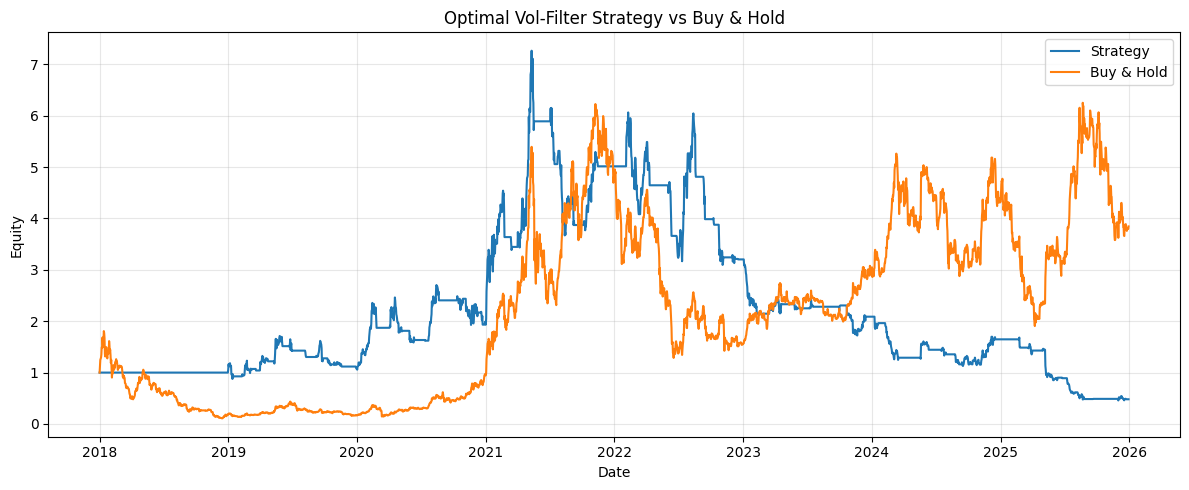

In [24]:
# Step 1: Find best parameters
print("Optimizing thresholds...")
optimization_results = rolling_find_thresholds(
    '../datasets/eth_macd_18_50_13_post_trade_table.csv', 
    '../datasets/eth_bollinger_post_trade_table.csv'
)

# Step 2: Load and merge data once for stitching
window = 365
step = 30

macd_df = pd.read_csv('../datasets/eth_macd_18_50_13_post_trade_table.csv')
boll_df = pd.read_csv('../datasets/eth_bollinger_post_trade_table.csv')
macd_df['date'] = pd.to_datetime(macd_df['date'], format='mixed')
boll_df['date'] = pd.to_datetime(boll_df['date'], format='mixed', dayfirst=True)

df = pd.merge(
    macd_df[['date','price','log_return','position']],
    boll_df[['date','position']],
    on='date', suffixes=('_macd','_boll')
).reset_index(drop=True)

df['vol_ratio'] = df['log_return'].rolling(30).std() / df['log_return'].rolling(90).std()
df['sma_slope'] = df['price'].rolling(20).mean().diff()

# Step 3: Stitch test slices using each window's own params
def apply_rules_with_params(df_slice, trend_t, range_t):
    regimes, current = [], 'Trend'
    for val in df_slice['vol_ratio']:
        if pd.isna(val):
            regimes.append(current)
            continue
        if val > trend_t:   current = 'Trend'
        elif val < range_t: current = 'Range'
        regimes.append(current)
    out = df_slice.copy()
    out['regime'] = regimes
    def rule(r):
        if r['regime'] == 'Trend':
            return r['position_macd'], 'macd'
        if r['position_boll'] == 1 and r['sma_slope'] < 0:
            return 0, 'neutral'
        return r['position_boll'], 'boll'
    res = out.apply(rule, axis=1)
    out['position'] = [x[0] for x in res]
    out['strategy_source'] = [x[1] for x in res]
    return out

slices = []
for i, row in enumerate(optimization_results.itertuples()):
    start = window + i * step
    end   = start + step
    if end > len(df):
        break
    slices.append(apply_rules_with_params(df.iloc[start:end], row.trend_t, row.range_t))

final_df = pd.concat(slices).sort_values('date').reset_index(drop=True)
final_df['trade'] = final_df['position'].diff().fillna(0).astype(int)
final_df['trade_action'] = final_df['trade'].map({1: 'buy', -1: 'sell', 0: 'hold'})
final_df.to_csv('eth_rolling_vol.csv', index=False)

print(f"Date range: {final_df['date'].min()} → {final_df['date'].max()}")
print(f"Total rows: {len(final_df)}")

asset_ret = final_df['price'].pct_change().fillna(0)
strat_ret = final_df['position'] * asset_ret


# Step 4: Join positions back onto full df, then evaluate
full_eval_df = df[['date','price','log_return']].copy()
full_eval_df = full_eval_df.merge(
    final_df[['date','position','trade','trade_action']],
    on='date',
    how='left'
)
full_eval_df['position'] = full_eval_df['position'].fillna(0).astype(int)
full_eval_df['trade'] = full_eval_df['trade'].fillna(0).astype(int)
full_eval_df['trade_action'] = full_eval_df['trade_action'].fillna('hold')

asset_ret = full_eval_df['price'].pct_change().fillna(0)
strat_ret = full_eval_df['position'] * asset_ret
print("Equity check (strategy):", (1 + strat_ret).cumprod().iloc[-1])
print("Equity check (buy&hold):", (1 + asset_ret).cumprod().iloc[-1])

daily_eval, trade_log, summary = evaluate_strategy_full(full_eval_df, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="Optimal Vol-Filter Strategy vs Buy & Hold")
plt.show()

### BTC

Optimizing thresholds...
Date range: 2019-01-01 00:00:00 → 2025-12-24 00:00:00
Total rows: 2550
Equity check (strategy): 0.33382258048547814
Equity check (buy&hold): 6.474982540187895

--- Final Strategy Performance ---
cumulative_pnl: -0.6662
average_daily_pnl: -0.0002
max_drawdown: -0.8253
annualised_return: -0.1281
sharpe_ratio_rf_3pct: -0.2294
daily_std_dev: 0.0205
annualised_volatility: 0.3917
exposure_rate: 0.3913
total_turnover: 169.0000
number_of_trades_total: 85.0000
number_of_complete_trades: 85.0000
win_rate: 0.4235
average_trade_return: -0.0027
median_trade_return: -0.0139
average_win_return: 0.1125
average_loss_return: -0.0872
profit_factor: 0.9473
payoff_ratio: 1.2894
expectancy_per_trade: -0.0027
best_trade: 0.5864
worst_trade: -0.3189
average_holding_periods: 13.4471
median_holding_periods: 12.0000
long_trades: 64.0000
short_trades: 21.0000


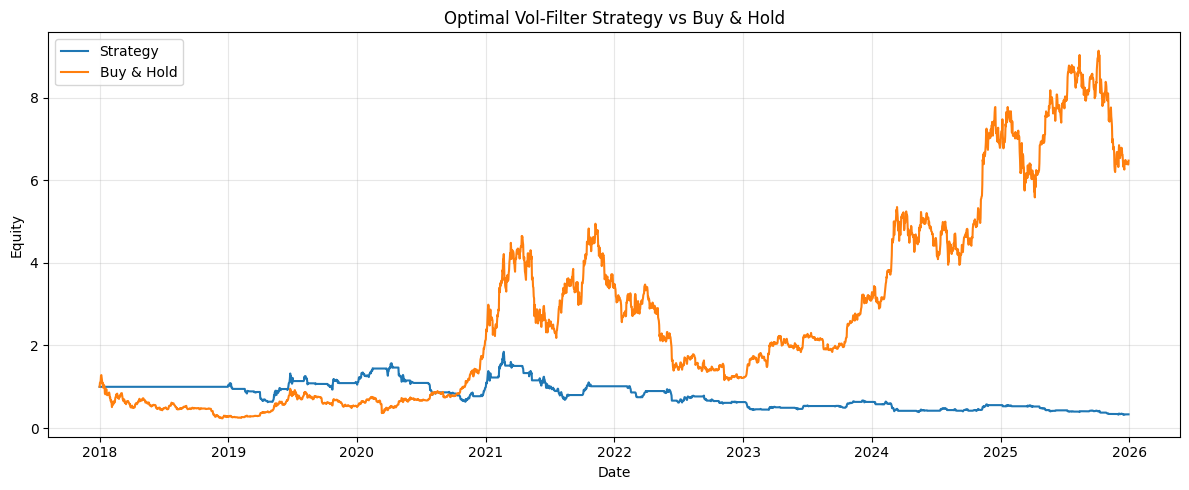

In [26]:
# Step 1: Find best parameters
print("Optimizing thresholds...")
optimization_results = rolling_find_thresholds(
    '../datasets/btc_macd_16_20_15_post_trade_table.csv', 
    '../datasets/btc_bollinger_post_trade_table.csv'
)

# Step 2: Load and merge data once for stitching
window = 365
step = 30

macd_df = pd.read_csv('../datasets/btc_macd_16_20_15_post_trade_table.csv')
boll_df = pd.read_csv('../datasets/btc_bollinger_post_trade_table.csv')
macd_df['date'] = pd.to_datetime(macd_df['date'], format='mixed')
boll_df['date'] = pd.to_datetime(boll_df['date'], format='mixed', dayfirst=True)

df = pd.merge(
    macd_df[['date','price','log_return','position']],
    boll_df[['date','position']],
    on='date', suffixes=('_macd','_boll')
).reset_index(drop=True)

df['vol_ratio'] = df['log_return'].rolling(30).std() / df['log_return'].rolling(90).std()
df['sma_slope'] = df['price'].rolling(20).mean().diff()

# Step 3: Stitch test slices using each window's own params
def apply_rules_with_params(df_slice, trend_t, range_t):
    regimes, current = [], 'Trend'
    for val in df_slice['vol_ratio']:
        if pd.isna(val):
            regimes.append(current)
            continue
        if val > trend_t:   current = 'Trend'
        elif val < range_t: current = 'Range'
        regimes.append(current)
    out = df_slice.copy()
    out['regime'] = regimes
    def rule(r):
        if r['regime'] == 'Trend':
            return r['position_macd'], 'macd'
        if r['position_boll'] == 1 and r['sma_slope'] < 0:
            return 0, 'neutral'
        return r['position_boll'], 'boll'
    res = out.apply(rule, axis=1)
    out['position'] = [x[0] for x in res]
    out['strategy_source'] = [x[1] for x in res]
    return out

slices = []
for i, row in enumerate(optimization_results.itertuples()):
    start = window + i * step
    end   = start + step
    if end > len(df):
        break
    slices.append(apply_rules_with_params(df.iloc[start:end], row.trend_t, row.range_t))

final_df = pd.concat(slices).sort_values('date').reset_index(drop=True)
final_df['trade'] = final_df['position'].diff().fillna(0).astype(int)
final_df['trade_action'] = final_df['trade'].map({1: 'buy', -1: 'sell', 0: 'hold'})
final_df.to_csv('btc_rolling_vol.csv', index=False)

print(f"Date range: {final_df['date'].min()} → {final_df['date'].max()}")
print(f"Total rows: {len(final_df)}")

asset_ret = final_df['price'].pct_change().fillna(0)
strat_ret = final_df['position'] * asset_ret


# Step 4: Join positions back onto full df, then evaluate
full_eval_df = df[['date','price','log_return']].copy()
full_eval_df = full_eval_df.merge(
    final_df[['date','position','trade','trade_action']],
    on='date',
    how='left'
)
full_eval_df['position'] = full_eval_df['position'].fillna(0).astype(int)
full_eval_df['trade'] = full_eval_df['trade'].fillna(0).astype(int)
full_eval_df['trade_action'] = full_eval_df['trade_action'].fillna('hold')

asset_ret = full_eval_df['price'].pct_change().fillna(0)
strat_ret = full_eval_df['position'] * asset_ret
print("Equity check (strategy):", (1 + strat_ret).cumprod().iloc[-1])
print("Equity check (buy&hold):", (1 + asset_ret).cumprod().iloc[-1])

daily_eval, trade_log, summary = evaluate_strategy_full(full_eval_df, fee=0.00, rf_annual=0.03)
print("\n--- Final Strategy Performance ---")
for k, v in summary.items():
    print(f"{k}: {v:.4f}")

plot_strategy_vs_buy_hold(daily_eval, title="Optimal Vol-Filter Strategy vs Buy & Hold")
plt.show()

Volatility Filter with rolling window:
This strategy implements a rolling window to find the optimal parameters for each window. How it works it that for each window (365 days), it finds the best parameters and apply it to the test (next 30 days). 